In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
data = pd.read_csv("irrigation.csv")

In [ ]:
data.shape

(16411, 7)

In [ ]:
data.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


In [ ]:
data.describe()

,MOI,temp,humidity,result
count,16411.000000,16411.000000,16411.000000,16411.000000
mean,43.695387,28.832612,63.487752,0.516178
std,27.160264,9.701465,22.630965,0.621691
min,1.000000,13.000000,15.000000,0.000000
25%,21.000000,20.000000,44.000000,0.000000
50%,41.000000,28.000000,69.200000,0.000000
75%,64.000000,37.000000,84.000000,1.000000
max,100.000000,46.000000,91.000000,2.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


In [ ]:
print(data.isnull().sum())#nb de colone des valeurs null par colonne

crop ID           0
soil_type         0
Seedling Stage    0
MOI               0
temp              0
humidity          0
result            0
dtype: int64


elle vous donne le nombre d'occurrences où le résultat est égal à 0.

In [ ]:
data[data['result'] == 0].shape[0]

9062

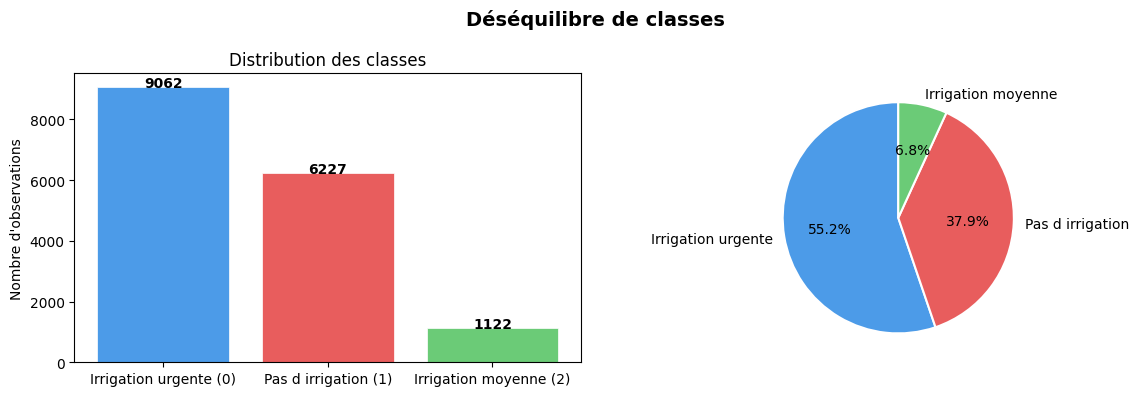


⚠️ Ratio irrigation urgente (0) : 55.2%
⚠️ Ratio pas d'irrigation (1) : 37.9%
⚠️ Ratio irrigation moyenne (2) : 6.8%

→ Un modèle naïf prédisant toujours la classe majoritaire aurait 55.2% d'accuracy sans rien apprendre !


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Distribution brute
counts = data['result'].value_counts().sort_index() #pour garantit le trie de la colonne result 0 1 2
axes[0].bar(    ['Irrigation urgente (0)', 'Pas d irrigation (1)', 'Irrigation moyenne (2)'], counts.values,
            color=['#4C9BE8', '#E85D5D','#6BCB77'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution des classes')
axes[0].set_ylabel('Nombre d\'observations')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pourcentages
axes[1].pie(
    counts.values,
    labels=['Irrigation urgente', 'Pas d irrigation', 'Irrigation moyenne'],
    autopct='%1.1f%%',
    colors=['#4C9BE8', '#E85D5D','#6BCB77'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.suptitle('Déséquilibre de classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

total = counts.sum()
print(f"\n Ratio irrigation urgente (0) : {counts.get(0,0)/total*100:.1f}%")
print(f" Ratio pas d'irrigation (1) : {counts.get(1,0)/total*100:.1f}%")
print(f" Ratio irrigation moyenne (2) : {counts.get(2,0)/total*100:.1f}%")

print("\n→ Un modèle naïf prédisant toujours la classe majoritaire aurait",
      f"{counts.max()/total*100:.1f}% d'accuracy sans rien apprendre !")

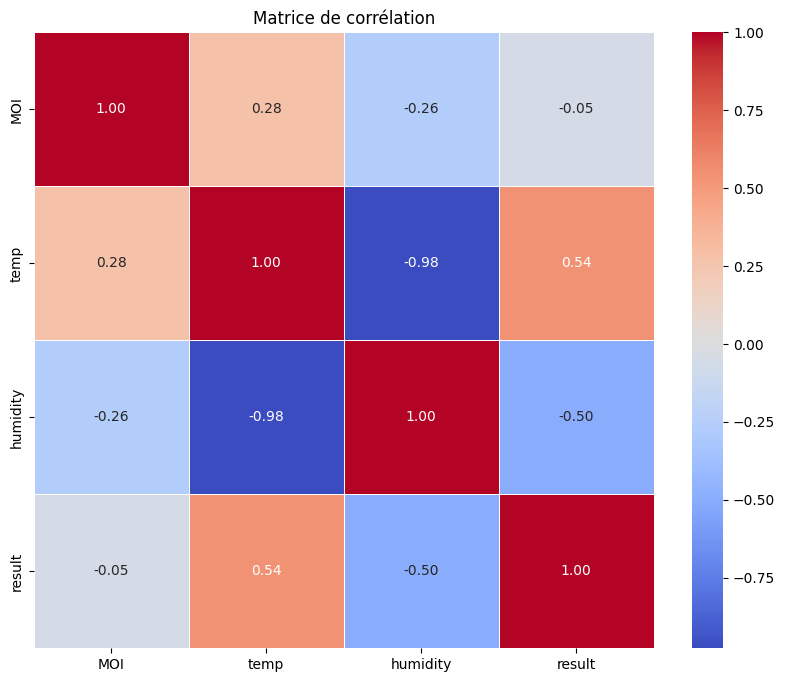

In [ ]:
corr = data.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, linecolor='white')

plt.title("Matrice de corrélation")
plt.show()

In [ ]:
# Séparation features / cible
features = ['MOI', 'temp', 'humidity']
X = data[features].copy()
y = data['result'].copy()

print(f"Features X : {X.shape}")
print(f"Cible    y : {y.shape}")
print(f"\nValeurs manquantes avant imputation :\n{X.isnull().sum()}")

Features X : (16411, 3)
Cible    y : (16411,)

Valeurs manquantes avant imputation :
MOI         0
temp        0
humidity    0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Split train / test STRATIFIÉ (préserve le ratio de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Test  : {X_test.shape[0]} exemples")
print(f"\nDistribution dans le train :")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nDistribution dans le test :")
print(y_test.value_counts(normalize=True).round(3))
print("\n✅ La stratification préserve le ratio 90/10 dans chaque split.")

Train : 13128 exemples
Test  : 3283 exemples

Distribution dans le train :
result
0    0.552
1    0.379
2    0.068
Name: proportion, dtype: float64

Distribution dans le test :
result
0    0.552
1    0.380
2    0.068
Name: proportion, dtype: float64

✅ La stratification préserve le ratio 90/10 dans chaque split.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Vérification
print("Moyenne des features après normalisation (train) :")
print(pd.DataFrame(X_train_scaled, columns=features).mean().round(4))
print("\nÉcart-type des features après normalisation (train) :")
print(pd.DataFrame(X_train_scaled, columns=features).std().round(4))
print("\n⚠️  Le scaler est fitté UNIQUEMENT sur le train pour éviter le data leakage !")

Moyenne des features après normalisation (train) :
MOI         0.0
temp       -0.0
humidity   -0.0
dtype: float64

Écart-type des features après normalisation (train) :
MOI         1.0
temp        1.0
humidity    1.0
dtype: float64

⚠️  Le scaler est fitté UNIQUEMENT sur le train pour éviter le data leakage !


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Régression Logistique avec gestion du déséquilibre
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("=== RÉGRESSION LOGISTIQUE ===")
print(classification_report(y_test, y_pred_lr,
                             target_names=["Irrigation urgente","Pas d'irrigation","Irrigation moyenne"]))

=== RÉGRESSION LOGISTIQUE ===
                    precision    recall  f1-score   support

Irrigation urgente       0.96      0.65      0.78      1813
  Pas d'irrigation       0.85      0.77      0.81      1246
Irrigation moyenne       0.20      0.81      0.32       224

          accuracy                           0.71      3283
         macro avg       0.67      0.75      0.64      3283
      weighted avg       0.87      0.71      0.76      3283



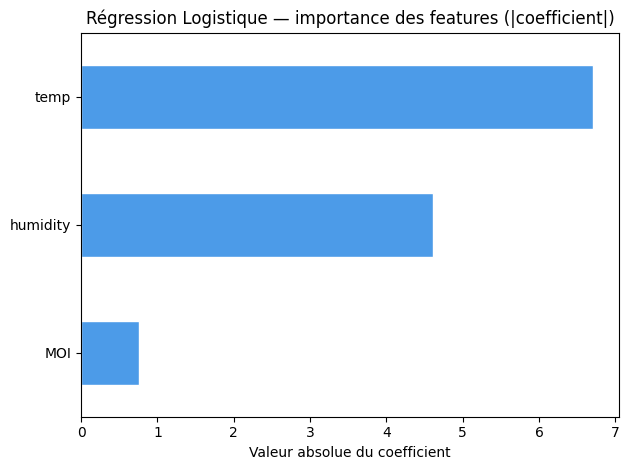

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importance des features (coefficients)
coefs = pd.Series(np.abs(lr.coef_[0]), index=features).sort_values(ascending=True)
coefs.plot(kind='barh', color='#4C9BE8', edgecolor='white')
plt.title('Régression Logistique — importance des features (|coefficient|)')
plt.xlabel('Valeur absolue du coefficient')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Arbre de décision
dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("=== ARBRE DE DÉCISION ===")
print(classification_report(y_test, y_pred_dt,
                             target_names=["Irrigation urgente","Pas d'irrigation","Irrigation moyenne"]))

=== ARBRE DE DÉCISION ===
                    precision    recall  f1-score   support

Irrigation urgente       1.00      0.81      0.89      1813
  Pas d'irrigation       0.93      0.89      0.91      1246
Irrigation moyenne       0.28      0.78      0.42       224

          accuracy                           0.84      3283
         macro avg       0.74      0.83      0.74      3283
      weighted avg       0.92      0.84      0.87      3283



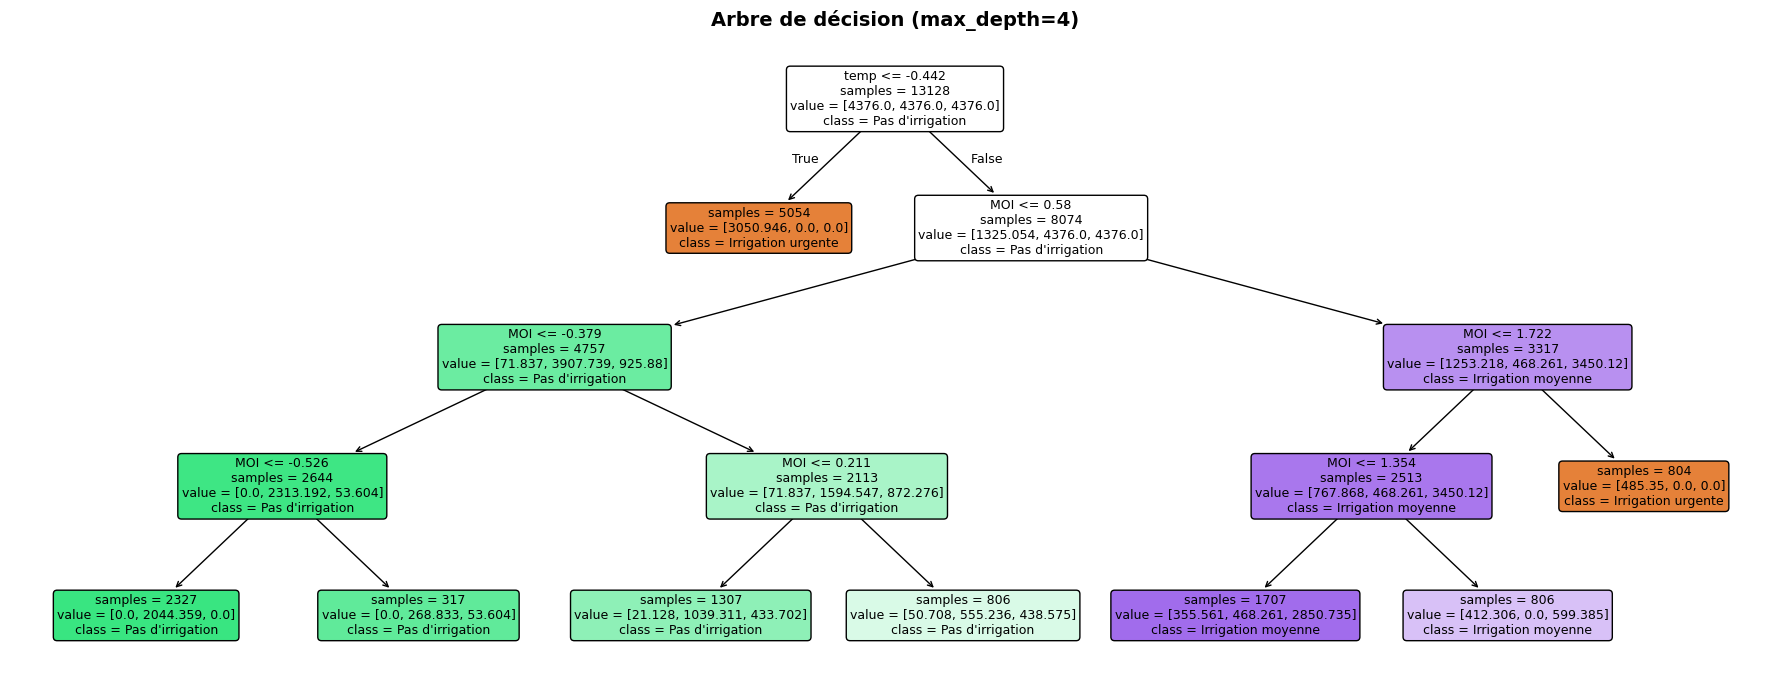

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 7))
plot_tree(dt, feature_names=features, class_names=["Irrigation urgente","Pas d'irrigation","Irrigation moyenne"],
          filled=True, rounded=True, fontsize=9,
          impurity=False, proportion=False)
plt.title('Arbre de décision (max_depth=4)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

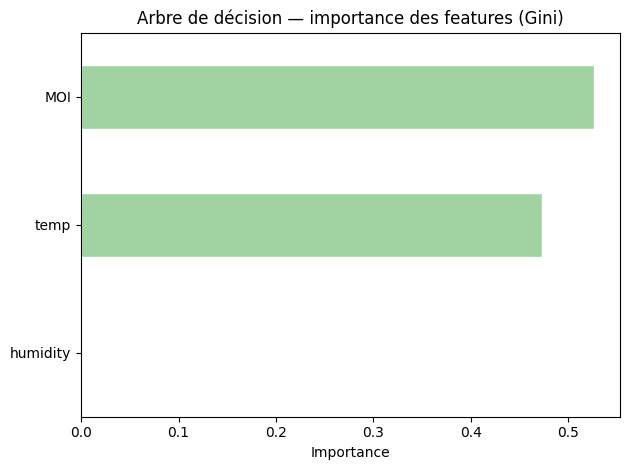

In [ ]:
importances = pd.Series(dt.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='#A1D2A1', edgecolor='white')
plt.title('Arbre de décision — importance des features (Gini)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# KNN
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("=== K-NEAREST NEIGHBORS (k=5) ===")
print(classification_report(y_test, y_pred_knn,
                             target_names=["Irrigation urgente","Pas d'irrigation","Irrigation moyenne"]))

=== K-NEAREST NEIGHBORS (k=5) ===
                    precision    recall  f1-score   support

Irrigation urgente       0.91      0.94      0.93      1813
  Pas d'irrigation       0.87      0.93      0.90      1246
Irrigation moyenne       0.25      0.11      0.15       224

          accuracy                           0.88      3283
         macro avg       0.68      0.66      0.66      3283
      weighted avg       0.85      0.88      0.86      3283



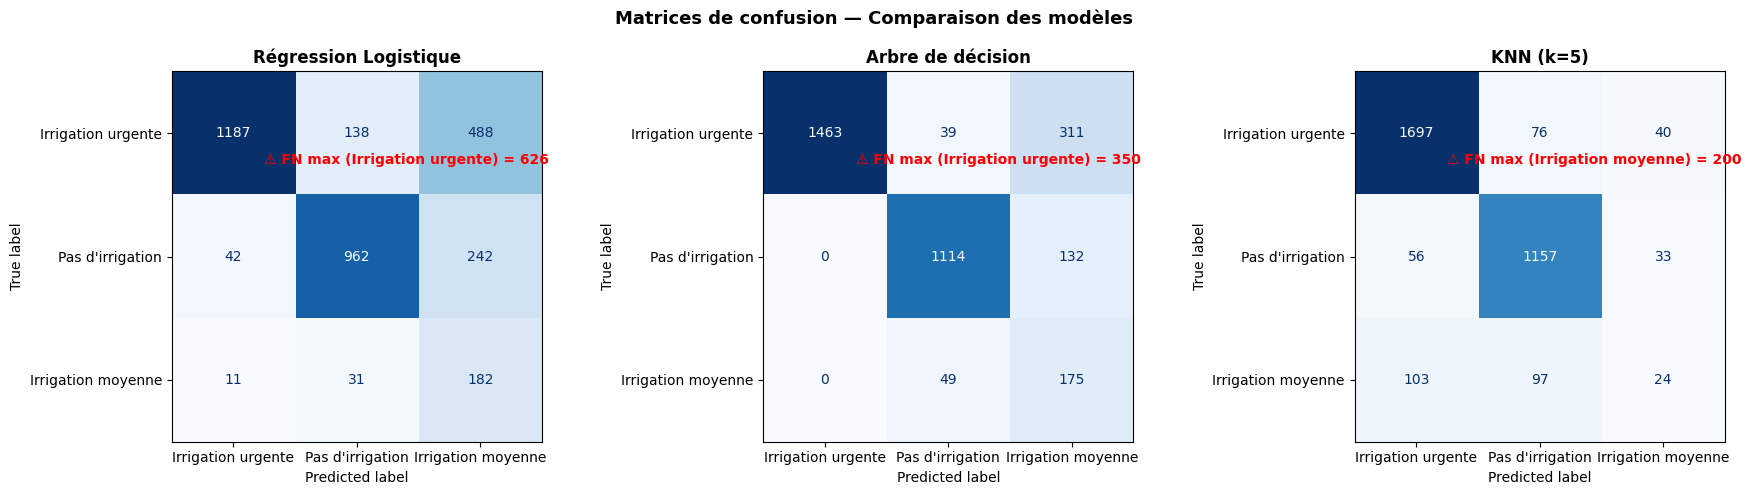

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    'Régression Logistique': y_pred_lr,
    'Arbre de décision':     y_pred_dt,
    'KNN (k=5)':             y_pred_knn
}

class_names = ["Irrigation urgente", "Pas d'irrigation", "Irrigation moyenne"]

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')


    fn_per_class = [(np.sum(cm[i, :]) - cm[i, i]) for i in range(len(class_names))]


    worst_class_idx = np.argmax(fn_per_class)
    worst_class_name = class_names[worst_class_idx]
    worst_fn = fn_per_class[worst_class_idx]


    ax.annotate(
        f'⚠️ FN max ({worst_class_name}) = {worst_fn}',
        xy=(0, 1),
        xytext=(0.25, 0.75),
        fontsize=10,
        color='red',
        fontweight='bold',
        textcoords='axes fraction'
    )

plt.suptitle('Matrices de confusion — Comparaison des modèles',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

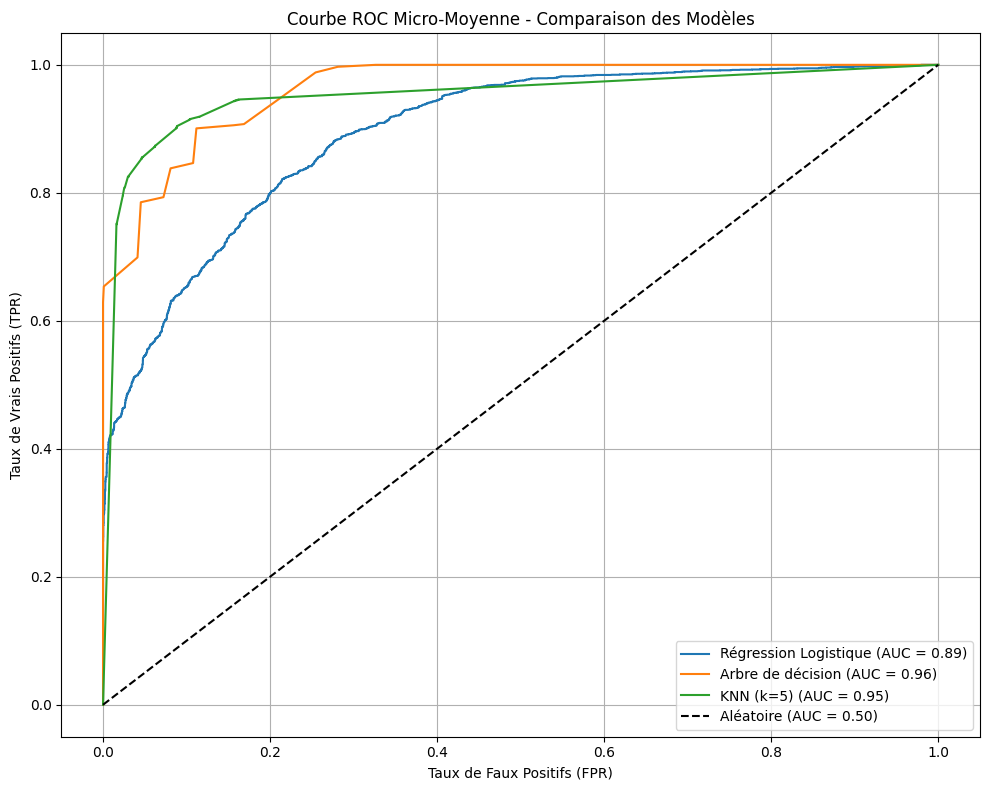

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc


label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)

models_for_roc = {
    'Régression Logistique': lr,
    'Arbre de décision': dt,
    'KNN (k=5)': knn
}

plt.figure(figsize=(10, 8))

for name, model in models_for_roc.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)


        fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    else:
        print(f"Le modèle {name} ne supporte pas predict_proba.")

plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC Micro-Moyenne - Comparaison des Modèles')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

La courbe ROC montre que **l’arbre de décision est le modèle le plus performant**, avec un AUC de 0,96, ce qui signifie qu’il distingue très bien les classes. Le modèle **KNN** est aussi très bon (AUC = 0,95), mais légèrement moins efficace. En revanche, la **régression logistique** est moins performante (AUC = 0,89), bien qu’elle reste correcte. Enfin, la ligne aléatoire (AUC = 0,50) représente un modèle sans capacité de discrimination. Ainsi, **l’arbre de décision est le meilleur choix parmi ces modèles**.


### Courbes ROC Individuelles par Modèle

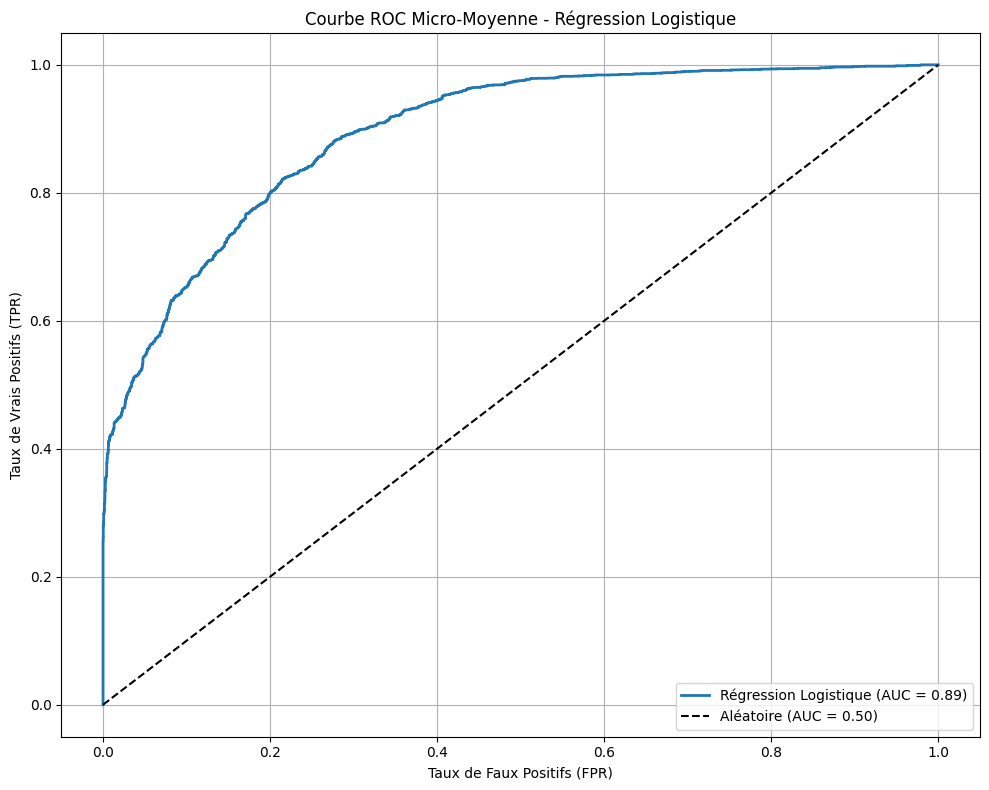

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)


plt.figure(figsize=(10, 8))

# Logistic Regression
name = 'Régression Logistique'
model = lr

if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_test_scaled)

    # Plot micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_micro:.2f})', linewidth=2)


plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC Micro-Moyenne - Régression Logistique')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

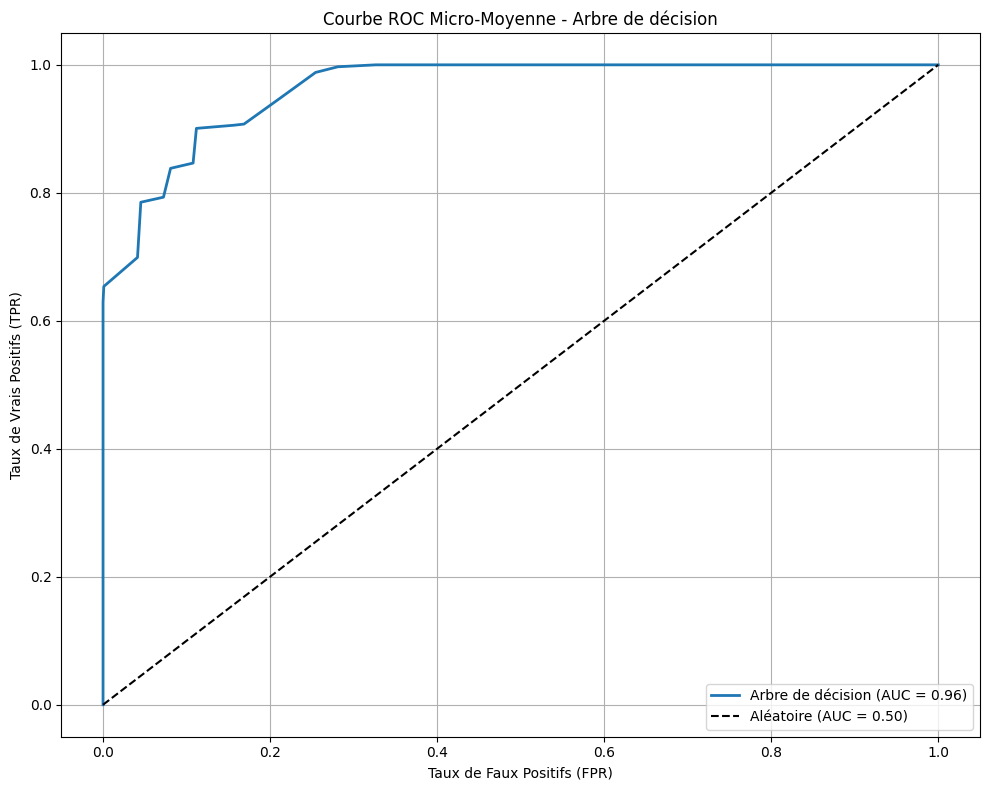

In [ ]:
plt.figure(figsize=(10, 8))

# Decision Tree
name = 'Arbre de décision'
model = dt

if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_test_scaled)

    # Plot micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_micro:.2f})', linewidth=2)


plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC Micro-Moyenne - Arbre de décision')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

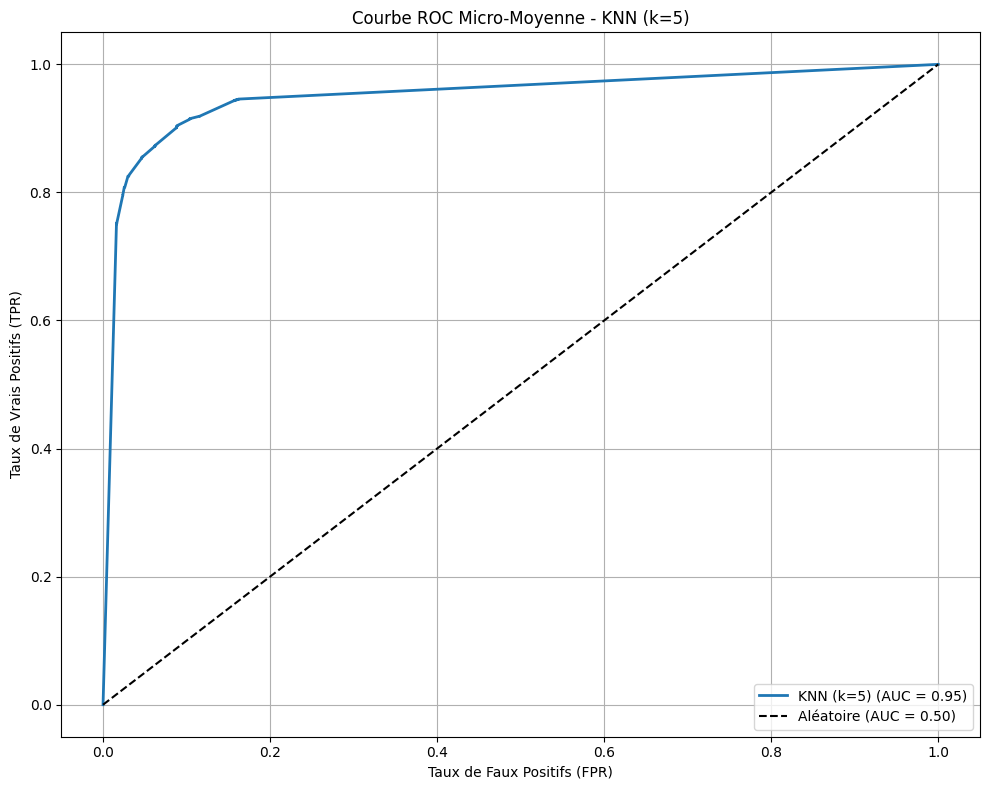

In [ ]:
plt.figure(figsize=(10, 8))

# KNN
name = 'KNN (k=5)'
model = knn

if hasattr(model, "predict_proba"):
    y_score = model.predict_proba(X_test_scaled)

    # Plot micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_micro:.2f})', linewidth=2)


plt.plot([0, 1], [0, 1], 'k--', label='Aléatoire (AUC = 0.50)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC Micro-Moyenne - KNN (k=5)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()